### Configuration

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
# os.environ["TF_DETERMINISTIC_OPS"] = "42"
# os.environ["TF_CUDNN_DETERMINISTIC"] = "42"

import random

import time

import sklearn

import joblib

import numpy as np

import jax
import jax.numpy as jnp

import tensorflow as tf
import tensorflow.keras as K

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import matplotlib.pyplot as plt

In [2]:
params = {
            "neurons" : [64, 512, 512, 4],    # The last one correspond to the output layer
        "activations" : ["tanh", "tanh", "tanh", "linear"],    # The last one correspond to the output layer
             "epochs" : 100,
                 "lr" : 5e-3,
               "loss" : "mse",
         "batch_size" : 256,
     "early_patience" : 10,
      "RLRonP_factor" : 0.6,
    "RLRonP_patience" : 7,
      "path_datasets" : "./../src/datasets/",
         "path_model" : "./../src/model/"
}

### Pre-processing data

In [3]:
def loadData():
    """
    Lo que se resuelve en el script numérico es con fR0, no con log10fR0.
    """
    path_datasets = params["path_datasets"]
    
    train         = np.loadtxt(path_datasets + "train.txt",      skiprows=1)
    validation    = np.loadtxt(path_datasets + "validation.txt", skiprows=1)
    test          = np.loadtxt(path_datasets + "test.txt",       skiprows=1)

    # for dataset in [train, validation, test]:
    #     dataset[:, 5] = 10 ** dataset[:, 5]
        
    print("Samples size:\n")
    print(f"Train: {len(train)} || val & test: {len(test)}.")

    return train, validation, test

In [4]:
def _createScaler():
    """
    Se crea un Scaler global para toda la instancia y se impiden problemas con la aleatoriedad.
    """
    global SSi
    global SSo
    SSi = sklearn.preprocessing.StandardScaler()
    SSo = sklearn.preprocessing.StandardScaler()
    return 0

In [5]:
def scaleData(data_set):
    """
    Divide los 6 imputs y 4 outputs ded cada data set.

    Se crea 2 SS y 2 scalers para input y output. Los scalers solo se crean con train
    para impedir que el modelo sepa de antemano información de validation o test.
    """
    i_set, o_set = data_set[:,:6], data_set[:,6:]    # (z, k1, k2, x12, om, logf), (A, Ap, B, Bp)

    if "SSi" not in globals() and "SSo" not in globals():
        _createScaler()

        global scaler_i
        global scaler_o
        scaler_i = SSi.fit(i_set)
        scaler_o = SSo.fit(o_set)
        
    return [scaler_i.transform(i_set), scaler_o.transform(o_set)]

### Model & training

In [6]:
def _createModel():
    """
    La arquitectura de la red está descrita por el dict arqui. 
    
    Es mutables para realizar muchas pruebas, pero el input y output siempre son los mismo.
    """
    neurons     = params["neurons"]
    activations = params["activations"]
    lr          = params["lr"]
    loss        = params["loss"]

    model = K.Sequential()
    model.add(K.Input(shape=(6,)))
    for n, func in zip(neurons, activations):
        model.add(K.layers.Dense(n, activation=func))

    model.compile(
        optimizer=K.optimizers.Adam(learning_rate=lr),
        loss=loss
    )

    model.summary()
    return model

In [7]:
def _callbacks():
    ES = K.callbacks.EarlyStopping
    RLRonP = K.callbacks.ReduceLROnPlateau

    early_patience  = params["early_patience"]
    RLRonP_factor   = params["RLRonP_factor"]
    RLRonP_patience = params["RLRonP_patience"]
    
    call_1 = ES(
        monitor               = 'val_loss',
        mode                  = "min",
        patience              = early_patience,
        restore_best_weights  = True,
        verbose               = 1,
    )

    call_2 = RLRonP(
        monitor   = 'val_loss',
        factor    = RLRonP_factor,
        patience  = RLRonP_patience,
        min_lr    = 1e-6,
        verbose   = 1
    )
            
    return [call_1, call_2]

In [8]:
def trainModel(scaled_train, scaled_val):
    """
    shuffle=True no afecta a Sobol ya que solo está cambiando el orden de cada uno de los sets,
    pero cada set ya está cubriendo todo el espacio.
    """
    epochs     = params["epochs"]
    batch_size = params["batch_size"]

    x_train, y_train = scaled_train[0], scaled_train[1]
    x_val, y_val     = scaled_val[0], scaled_val[1]
    model = _createModel()

    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        validation_data=(x_val, y_val),
        verbose=2,
        callbacks=_callbacks(),
    )

    return history, model

In [9]:
def saveModel(model):
    path_model = params["path_model"]
    
    joblib.dump(scaler_i, path_model + "scaler_i.pkl")
    joblib.dump(scaler_o, path_model + "scaler_o.pkl")
    
    model.save(path_model + "model.keras")

### Post-processing data

In [10]:
def _unScaleData(data):
    """
    Aplica el escalamiento inverso para obtener los valores en los rangos originales.bien. 
    """
    return scaler_o.inverse_transform(data)

### Data validation

In [11]:
def _makePrediction(model, x_data):
    batch_size = params["batch_size"]

    prediction = model.predict(
        x_data,
        batch_size=batch_size,
        verbose=0,
    )

    return prediction

In [12]:
def relError(model, scaled_data):
    scaled_x, scaled_y = scaled_data[0], scaled_data[1]
    scaled_y_predic    = _makePrediction(model, scaled_x)

    unscaled_y         = _unScaleData(scaled_y)
    unscaled_y_predic  = _unScaleData(scaled_y_predic)
        
    #unscaled_rel_error = (unscaled_y - unscaled_y_predic) * 100
    unscaled_rel_error = (1 - unscaled_y_predic / unscaled_y) * 100

    return unscaled_rel_error

In [13]:
def calcPercentil(error):
    r_names = ["A", "Ap", "B", "Bp"]
    rows = len(r_names)

    print(f"Percentil 99 for unscaled data in relative percentual error")
    print(20 * "=")
    for r in range(rows):
        perc = np.percentile(np.abs(error.T[r]), 99)
        print(f"{r_names[r]:>4}: {perc:.6f}%")
    print(20 * "=")

### Plotting

In [14]:
def plotLossFunction(history):
    succ_epochs = len(history.history['loss'])
    plt.figure(figsize=(10,7))
    x_axis = np.linspace(1, succ_epochs, succ_epochs)
    plt.semilogy(x_axis, history.history['loss'], 'r--', label='Train')
    plt.semilogy(x_axis, history.history['val_loss'], 'b-', label='Validation')
    plt.legend()
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.show()

In [15]:
def plotRelError(rel_error):
    rows, cols = 2, 2
    names = ["A", "Ap", "B", "Bp"]
    
    fig, axes = plt.subplots(rows, cols, figsize=(14,10))

    for c in range(cols):
        for r in range(rows):
            axes[r, c].hist(
                rel_error.T[r * 2 + c],
                bins=40,
                #range=(-1, 1),
                log=True,
                orientation="horizontal",
            )
            axes[r, c].set_xlabel("Frecuency", fontsize=18)
            axes[r, c].set_ylabel(r"$\Delta y$%", fontsize=18)
            axes[r, c].tick_params(
                axis="both",
                labelsize=14,
            )
            axes[r, c].set_title(f"Error relativo porcentual de {names[r * 2 + c]}")

    plt.show()

### Evaluation

In [16]:
train, validation, test = loadData()

Samples size:

Train: 4194304 || val & test: 1048576.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,436 (1.14 MB)

 Trainable params: 298,436 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16384/16384 - 35s - 2ms/step - loss: 0.0257 - val_loss: 0.0056 - learning_rate: 0.0050
Epoch 2/100
16384/16384 - 26s - 2ms/step - loss: 0.0074 - val_loss: 0.0069 - learning_rate: 0.0050
Epoch 3/100
16384/16384 - 26s - 2ms/step - loss: 0.0063 - val_loss: 0.0043 - learning_rate: 0.0050
Epoch 4/100
16384/16384 - 25s - 2ms/step - loss: 0.0058 - val_loss: 0.0070 - learning_rate: 0.0050
Epoch 5/100
16384/16384 - 26s - 2ms/step - loss: 0.0054 - val_loss: 0.0025 - learning_rate: 0.0050
Epoch 6/100
16384/16384 - 26s - 2ms/step - loss: 0.0055 - val_loss: 0.0079 - learning_rate: 0.0050
Epoch 7/100
16384/16384 - 26s - 2ms/step - loss: 0.0052 - val_loss: 0.0039 - learning_rate: 0.0050
Epoch 8/100
16384/16384 - 26s - 2ms/step - loss: 0.0051 - val_loss: 0.0044 - learning_rate: 0.0050
Epoch 9/100
16384/16384 - 26s - 2ms/step - loss: 0.0050 - val_loss: 0.0061 - learning_rate: 0.0050
Epoch 10/100
16384/16384 - 30s - 2ms/step - loss: 0.0048 - val_loss: 0.0026 - learning_rate: 0.0050
Epoch 11/

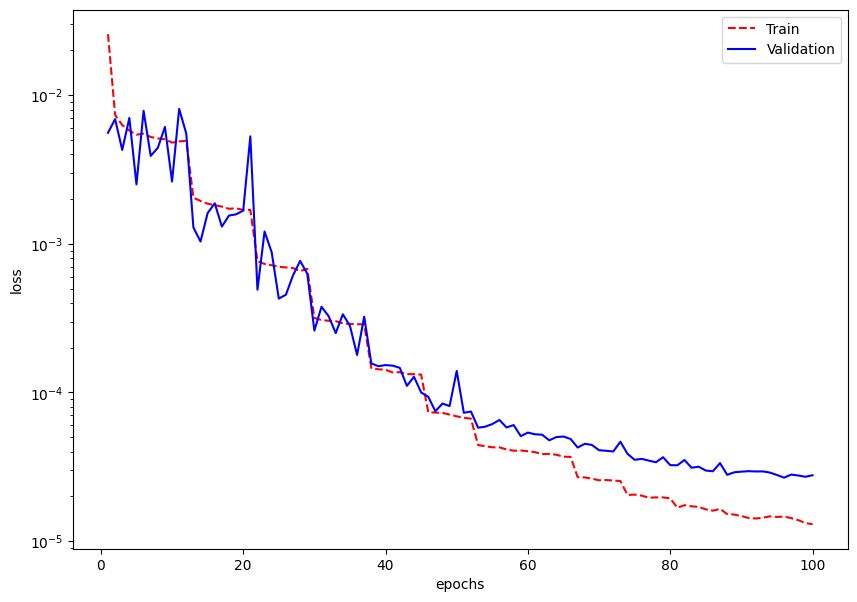

CPU times: user 1h 2min 51s, sys: 6min 42s, total: 1h 9min 33s
Wall time: 47min


In [17]:
%%time
scaled_train = scaleData(train)
scaled_val = scaleData(validation)

history, model = trainModel(scaled_train, scaled_val)
plotLossFunction(history)
saveModel(model)

In [18]:
scaled_test = scaleData(test)

unscaled_rel_error = relError(model, scaled_test)
calcPercentil(unscaled_rel_error)

Percentil 99 for unscaled data in relative percentual error
   A: 0.029097%
  Ap: 33.220256%
   B: 0.013816%
  Bp: 29.817168%
